## 中カテゴリあたり固有名詞の数

In [1]:
import pandas as pd
import json
import os

whole_df = pd.DataFrame()
for filename in os.listdir("../data/dbpedia/wikidata_Things_childs_LIMIT1000"):
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join("../data/dbpedia/wikidata_Things_childs_LIMIT1000", filename))
        whole_df = pd.concat([whole_df, df], ignore_index=True)
print(f"Total proper nouns collected: {len(whole_df)}")
whole_df.head()

Total proper nouns collected: 159610


,qid,label,class_label,class_qid
0,Q137919338,Colombian National Cross-Country Skiing,swimmer,Q10843402
1,Q12512,St. Peter's Basilica,church,Q16970
2,Q48435,Basilica and Expiatory Church of the Holy Family,church,Q16970
3,Q5933,Westminster Abbey,church,Q16970
4,Q2943,Sistine Chapel,church,Q16970


In [2]:

# 中カテゴリごとの固有名詞の数をカウントし、dfにする
category_count_df = whole_df.groupby("class_label").size().reset_index(name="count")
category_count_df


,class_label,count
0,Algorithm,421
1,Altitude,2
2,Archive,443
3,Band,1000
4,Biomolecule,7
...,...,...
274,woman,8
275,writer,19
276,written work,1000
277,year,597


In [3]:
# 50未満の固有名詞しかないカテゴリを抽出する
filtered_category_count_df = category_count_df[category_count_df["count"] < 50]
print(f"50未満の固有名詞しかないカテゴリの数: {filtered_category_count_df.shape[0]}")
filtered_category_count_df

50未満の固有名詞しかないカテゴリの数: 63


,class_label,count
1,Altitude,2
4,Biomolecule,7
5,Chief,5
15,Lawyer,13
21,Nobel Prize,37
...,...,...
246,swimmer,1
251,television host,3
267,vice president,3
274,woman,8


In [ ]:
whole_df[whole_df["class_label"] == "battery"]["label"].tolist()

['Silver-cadmium battery', 'Nanopore battery']

In [11]:
# 150以上の固有名詞があるカテゴリを抽出する
filtered_category_count_df = category_count_df[category_count_df["count"] >= 150]
print(f"150以上の固有名詞があるカテゴリの数: {filtered_category_count_df.shape[0]}")
filtered_category_count_df

150以上の固有名詞があるカテゴリの数: 195


,class_label,count
0,Algorithm,421
2,Archive,443
3,Band,1000
6,Disease,1000
7,Election,1000
...,...,...
272,wine,184
273,winery,630
276,written work,1000
277,year,597


In [12]:
# 150以上の固有名詞があるカテゴリについて、属する固有名詞のリストを作成する
filtered_categories = filtered_category_count_df["class_label"].tolist()
filtered_category_properNouns_dict = {}
for category in filtered_categories:
    properNouns = whole_df[whole_df["class_label"] == category]["label"].tolist()
    filtered_category_properNouns_dict[category] = properNouns

# 表示
for category, properNouns in filtered_category_properNouns_dict.items():
    print(f"Category: {category}, Proper Nouns Count: {len(properNouns)} {properNouns[:5]}")

Category: Algorithm, Proper Nouns Count: 421 ['sieve of Eratosthenes', 'quicksort', 'Gaussian elimination', 'Monte Carlo method', "Dijkstra's algorithm"]
Category: Archive, Proper Nouns Count: 443 ['Wayback Machine', 'Internet Archive', 'United States Census Bureau', 'Yad Vashem', 'Italian National Institute of Statistics']
Category: Band, Proper Nouns Count: 1000 ['ABBA', 'The Rolling Stones', 'Simon & Garfunkel', 't.A.T.u.', 'The White Stripes']
Category: Disease, Proper Nouns Count: 1000 ['HIV/AIDS', 'malaria', 'influenza', 'cholera', 'rabies']
Category: Election, Proper Nouns Count: 1000 ['2017 United Kingdom general election', '2025 German federal election', '2019 United Kingdom general election', '2013 conclave', '2018 Italian general election']
Category: EthnicGroup, Proper Nouns Count: 1000 ['Jewish people', 'Aztec', 'Romani people', 'African Americans', 'Turks']
Category: Flag, Proper Nouns Count: 1475 ['flag of Canada', 'flag of Europe', 'flag of Peru', 'flag of Vatican City'

In [14]:
filtered_category_properNouns_dict['Algorithm']

['sieve of Eratosthenes',
 'quicksort',
 'Gaussian elimination',
 'Monte Carlo method',
 "Dijkstra's algorithm",
 'binary search algorithm',
 'merge sort',
 "Newton's method",
 "Cramer's rule",
 'insertion sort',
 'reinforcement learning',
 'integration by parts',
 'transport layer',
 'Huffman coding',
 'integration by substitution',
 'unsupervised learning',
 'one-time pad',
 'linear search',
 "Prim's algorithm",
 "Shor's algorithm",
 'shellsort',
 'FIFO',
 'Face ID',
 "Kruskal's algorithm",
 'k-means clustering',
 'critical path method',
 'gradient descent',
 'backpropagation',
 'Atbash',
 'round-robin scheduling',
 'Gauss–Seidel method',
 'long division',
 'Delaunay triangulation',
 "Grover's algorithm",
 "Bresenham's line algorithm",
 'Wallis product',
 'expectation–maximization algorithm',
 'Lempel–Ziv–Welch',
 'self-organizing map',
 'Leibniz formula for π',
 'Miller–Rabin primality test',
 'Password Authentication Protocol',
 'neusis construction',
 'Strassen algorithm',
 'run-t

## 手動で固有名詞とその中カテゴリとのcos類似度を計算し、分布を調べる

In [4]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


/home/toko/project/EmbedNewConcept-20260305/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# モデル名
model_name = f"google/gemma-3-1b-it"

# tokenizer と model を読み込み
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# embedding層を取得
embedding_layer = model.get_input_embeddings()
embedding_weight = embedding_layer.weight  # shape: [vocab_size, hidden_size]

# 比較したい2つのtoken
token1 = "cat"
token2 = "dog"

# token → id
id1 = tokenizer.convert_tokens_to_ids(token1)
id2 = tokenizer.convert_tokens_to_ids(token2)

# embeddingベクトル取得
vec1 = embedding_weight[id1]
vec2 = embedding_weight[id2]

# cos類似度計算
cos_sim = F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0))

print(f"Cosine similarity between '{token1}' and '{token2}': {cos_sim.item():.4f}")

Some weights of Gemma3TextModel were not initialized from the model checkpoint at google/gemma-3-1b-it and are newly initialized: ['embed_tokens.weight', 'layers.0.input_layernorm.weight', 'layers.0.mlp.down_proj.weight', 'layers.0.mlp.gate_proj.weight', 'layers.0.mlp.up_proj.weight', 'layers.0.post_attention_layernorm.weight', 'layers.0.post_feedforward_layernorm.weight', 'layers.0.pre_feedforward_layernorm.weight', 'layers.0.self_attn.k_norm.weight', 'layers.0.self_attn.k_proj.weight', 'layers.0.self_attn.o_proj.weight', 'layers.0.self_attn.q_norm.weight', 'layers.0.self_attn.q_proj.weight', 'layers.0.self_attn.v_proj.weight', 'layers.1.input_layernorm.weight', 'layers.1.mlp.down_proj.weight', 'layers.1.mlp.gate_proj.weight', 'layers.1.mlp.up_proj.weight', 'layers.1.post_attention_layernorm.weight', 'layers.1.post_feedforward_layernorm.weight', 'layers.1.pre_feedforward_layernorm.weight', 'layers.1.self_attn.k_norm.weight', 'layers.1.self_attn.k_proj.weight', 'layers.1.self_attn.o_pr

Cosine similarity between 'cat' and 'dog': -0.0074


In [15]:

def get_mean_embedding(text):
    """tokenizeの結果、複数tokenになる場合は、各tokenのembeddingの平均を取る
    """
    # tokenize（special tokenは除く）
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"Text: {text}, Tokens: {tokens}, Token IDs: {token_ids}")

    # 各トークンのembedding取得
    vecs = embedding_weight[token_ids]  # shape: [num_tokens, hidden_size]

    # 平均を取る
    mean_vec = vecs.mean(dim=0)

    return mean_vec


def compute_cosine_similarity(text1, text2):
    vec1 = get_mean_embedding(text1)
    vec2 = get_mean_embedding(text2)
    
    cos_sim = F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0))
    return cos_sim.item()

In [16]:
category = 'enzyme'
properNoun = 'lactase'
compute_cosine_similarity(category, properNoun)
print(f"Cosine similarity between '{category}' and '{properNoun}': {compute_cosine_similarity(category, properNoun):.4f}")

Text: enzyme, Tokens: ['enzyme'], Token IDs: [109622]
Text: lactase, Tokens: ['lact', 'ase'], Token IDs: [144290, 781]
Text: enzyme, Tokens: ['enzyme'], Token IDs: [109622]
Text: lactase, Tokens: ['lact', 'ase'], Token IDs: [144290, 781]
Cosine similarity between 'enzyme' and 'lactase': 0.0027


In [11]:
whole_df.head()

,qid,label,class_label,class_qid
0,Q379764,lactase,enzyme,Q8047
1,Q416589,maltase,enzyme,Q8047
2,Q10891385,Sucrose alpha-glucosidase,enzyme,Q8047
3,Q5332143,Ecarin,enzyme,Q8047
4,Q7811495,Tobacco acid pyrophosphatase,enzyme,Q8047


In [ ]:
from tqdm import tqdm

for idx, row in tqdm(whole_df.iterrows(), total=whole_df.shape[0]):
    category = row['class_label']
    properNoun = row['label']
    cos_sim = compute_cosine_similarity(category, properNoun)
    # print(f"Cosine similarity between '{category}' and '{properNoun}': {cos_sim:.4f}")
    # whole_dfにcos_simの列を追加して、そこに値を入れる
    whole_df.at[idx, 'cosine_similarity_gemma3_1b_it'] = cos_sim

whole_df.head()

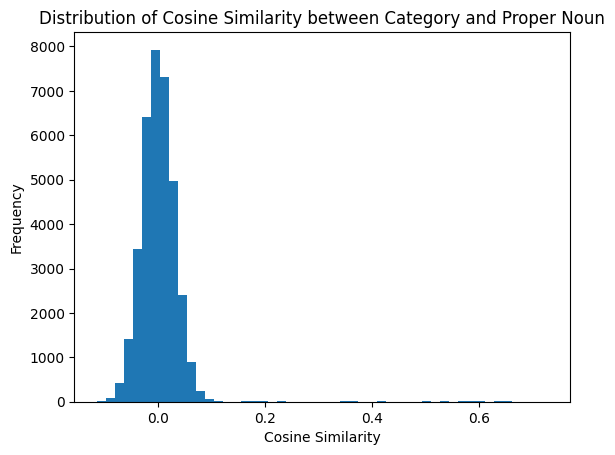

In [43]:
# cosine_similarityの分布を表示
import matplotlib.pyplot as plt
plt.hist(whole_df['cosine_similarity_gemma3_1b_it'], bins=50)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Cosine Similarity between Category and Proper Noun')
plt.show()

In [33]:
# -1.0~1.0の範囲で、0.1刻みのbinを作り、各binに何個入っているかを表で示す
import numpy as np
bins = list(np.arange(-1.0, 0.0, 0.1)) + list(np.arange(0.0, 1.1, 0.1))  # -1.0から1.0まで0.1刻みのbinを作成
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=bins).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(-1.0, -0.9]",0
1,"(-0.9, -0.8]",0
2,"(-0.8, -0.7]",0
3,"(-0.7, -0.6]",0
4,"(-0.6, -0.5]",0
5,"(-0.5, -0.4]",0
6,"(-0.4, -0.3]",0
7,"(-0.3, -0.2]",0
8,"(-0.2, -0.1]",6
9,"(-0.1, 0.0]",18132


In [ ]:
# 各binに何個入っているかを表で示す
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=10).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(-0.116, -0.0305]",5345
1,"(-0.0305, 0.0538]",29033
2,"(0.0538, 0.138]",1218
3,"(0.138, 0.222]",24
4,"(0.222, 0.307]",17
5,"(0.307, 0.391]",20
6,"(0.391, 0.475]",26
7,"(0.475, 0.559]",23
8,"(0.559, 0.644]",39
9,"(0.644, 0.728]",17


In [34]:
whole_df.head()

,qid,label,class_label,class_qid,cosine_similarity_gemma3_1b_it
0,Q379764,lactase,enzyme,Q8047,0.002698
1,Q416589,maltase,enzyme,Q8047,-0.055105
2,Q10891385,Sucrose alpha-glucosidase,enzyme,Q8047,0.032907
3,Q5332143,Ecarin,enzyme,Q8047,-0.061189
4,Q7811495,Tobacco acid pyrophosphatase,enzyme,Q8047,0.006395


### 0.0~1.0の範囲で、0.1刻みのbinを作り、各binに含まれるclass_labelの数を表で示す

In [35]:

bins = list(np.arange(0.0, 1.1, 0.1))  # -1.0から1.0まで0.1刻みのbinを作成
# 0.0~1.0の範囲で、0.1刻みのbinを作り、各binに含まれるclass_labelの数を表で示す
bin_counts = pd.cut(whole_df['cosine_similarity_gemma3_1b_it'], bins=bins).value_counts().sort_index()
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Cosine Similarity Range', 'Count']
bin_counts_df

,Cosine Similarity Range,Count
0,"(0.0, 0.1]",17431
1,"(0.1, 0.2]",44
2,"(0.2, 0.3]",23
3,"(0.3, 0.4]",22
4,"(0.4, 0.5]",36
5,"(0.5, 0.6]",36
6,"(0.6, 0.7]",28
7,"(0.7, 0.8]",4
8,"(0.8, 0.9]",0
9,"(0.9, 1.0]",0


In [37]:

df = whole_df.copy()  # 例としてwhole_dfを使用

# ① 0.0〜1.0 の bin を作成
bins = np.arange(0.0, 1.1, 0.1)

# ② bin に分類
df["cos_bin"] = pd.cut(
    df["cosine_similarity_gemma3_1b_it"],
    bins=bins,
    include_lowest=True
)

# ③ bin × class_label の件数を集計
result = (
    df.groupby(["cos_bin", "class_label"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

result

/tmp/ipykernel_895604/735376154.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cos_bin", "class_label"])


class_label,Algorithm,Disease,Employer,EthnicGroup,Flag,Hormone,Media,MedicalSpecialty,Medicine,Mill,...,television show,top level domain,tower,train,tunnel,vein,weapon,written work,year,zoo
cos_bin,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 0.1]",174,544,24,541,33,4,487,28,70,121,...,459,263,463,57,408,16,30,409,286,196
"(0.1, 0.2]",0,2,0,0,0,0,2,0,0,0,...,0,0,4,0,0,0,0,0,0,0
"(0.2, 0.3]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.3, 0.4]",0,0,0,1,1,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,0
"(0.4, 0.5]",0,0,0,0,2,0,0,0,0,4,...,0,0,12,0,7,0,0,0,0,0
"(0.5, 0.6]",0,0,0,0,0,0,0,0,0,0,...,0,0,3,0,3,0,0,0,0,0
"(0.6, 0.7]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.7, 0.8]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"(0.8, 0.9]",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
print(result)

class_label    Algorithm  Disease  Employer  EthnicGroup  Flag  Hormone  \
cos_bin                                                                   
(-0.001, 0.1]        174      544        24          541    33        4   
(0.1, 0.2]             0        2         0            0     0        0   
(0.2, 0.3]             0        0         0            0     0        0   
(0.3, 0.4]             0        0         0            1     1        0   
(0.4, 0.5]             0        0         0            0     2        0   
(0.5, 0.6]             0        0         0            0     0        0   
(0.6, 0.7]             0        0         0            0     0        0   
(0.7, 0.8]             0        0         0            0     0        0   
(0.8, 0.9]             0        0         0            0     0        0   
(0.9, 1.0]             0        0         0            0     0        0   

class_label    Media  MedicalSpecialty  Medicine  Mill  ...  television show  \
cos_bin            

## word2vecで同様にcos類似度を計算し、分布を調べる
→model消しちゃったっぽい。やるなら.bzのダウンロードからやり直し

In [29]:
pwd

'/home/toko/project/EmbedNewConcept/data/dbpedia'

In [30]:

from wikipedia2vec import Wikipedia2Vec
from wikipedia2vec.dictionary import Entity, Word

model_path = os.path.join("../../enwiki_20180420_300d.pkl") #.bz2")  # 例：300d (bin)
w2v = Wikipedia2Vec.load(model_path)

FileNotFoundError: [Errno 2] No such file or directory: '../../enwiki_20180420_300d.pkl'